## DACO PROJECT
Attempt to decide some models for the PV dataset.

In [4]:
# Import libraries
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("pv_module_efficiency_dataset.csv")
#data = data.dropna()
filtered_data = data[
    ~(
        (data['hotspot'] == 'None') &
        (data['birddrop'] == 'None') &
        (data['soiling'] == 'None') &
        (data['junction_box'] == 'None') &
        (data['affected_area'] > 0)
    )
]

# Separate the input features and target variables (output)
X = filtered_data.drop(["expected_efficiency", "efficiency_level"], axis=1)  # Input features
y_efficiency = filtered_data['expected_efficiency']  # Continuous target
y_efficiency_level = filtered_data['efficiency_level']  # Categorical target

### Dummy variables
Most ML algorithms require that the target variable be numerical, but categorical 
data often comes as text labels (e.g., "Monocrystalline," "Polycrystalline"). 

Dummy variables provide a way to represent these categories numerically without implying an ordinal
relationship (e.g., one category being "higher" or "lower" than another).

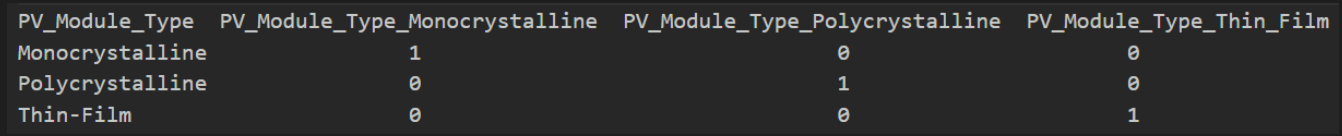

In [5]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, columns=['pv_module_type', 'hotspot', 'birddrop', 'soiling', 'junction_box'])

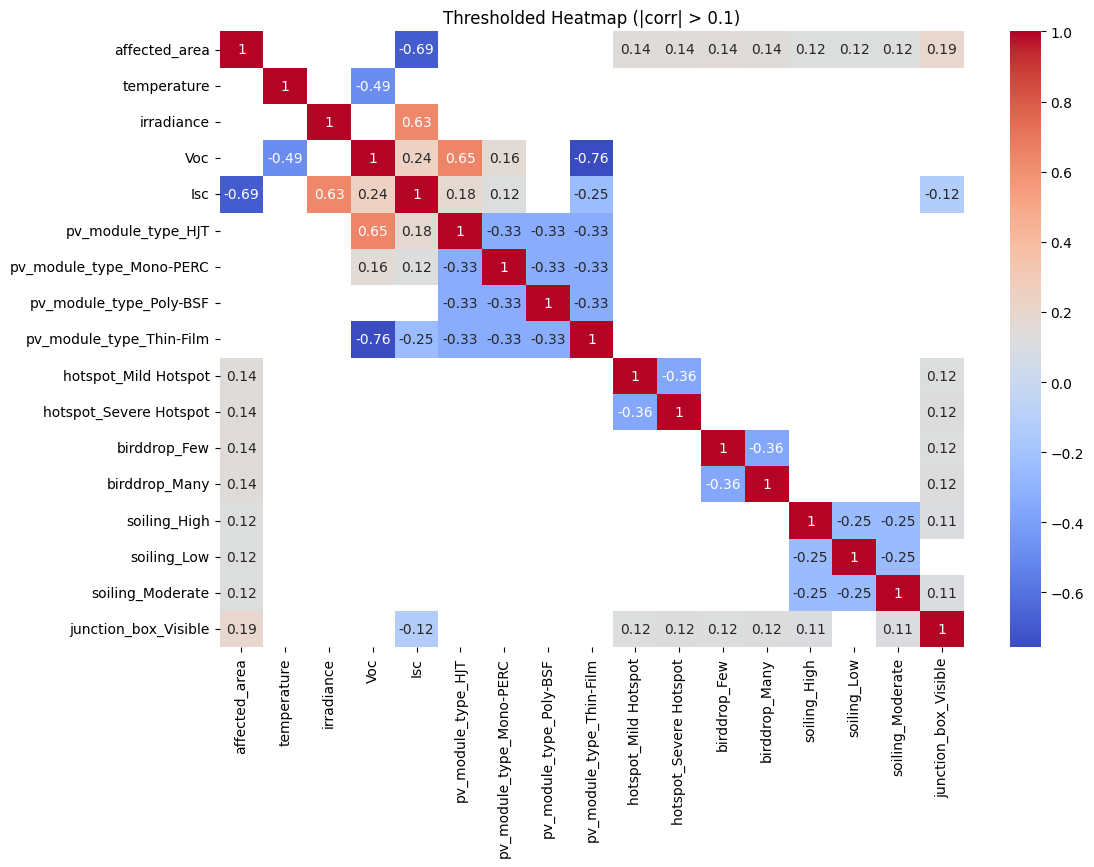

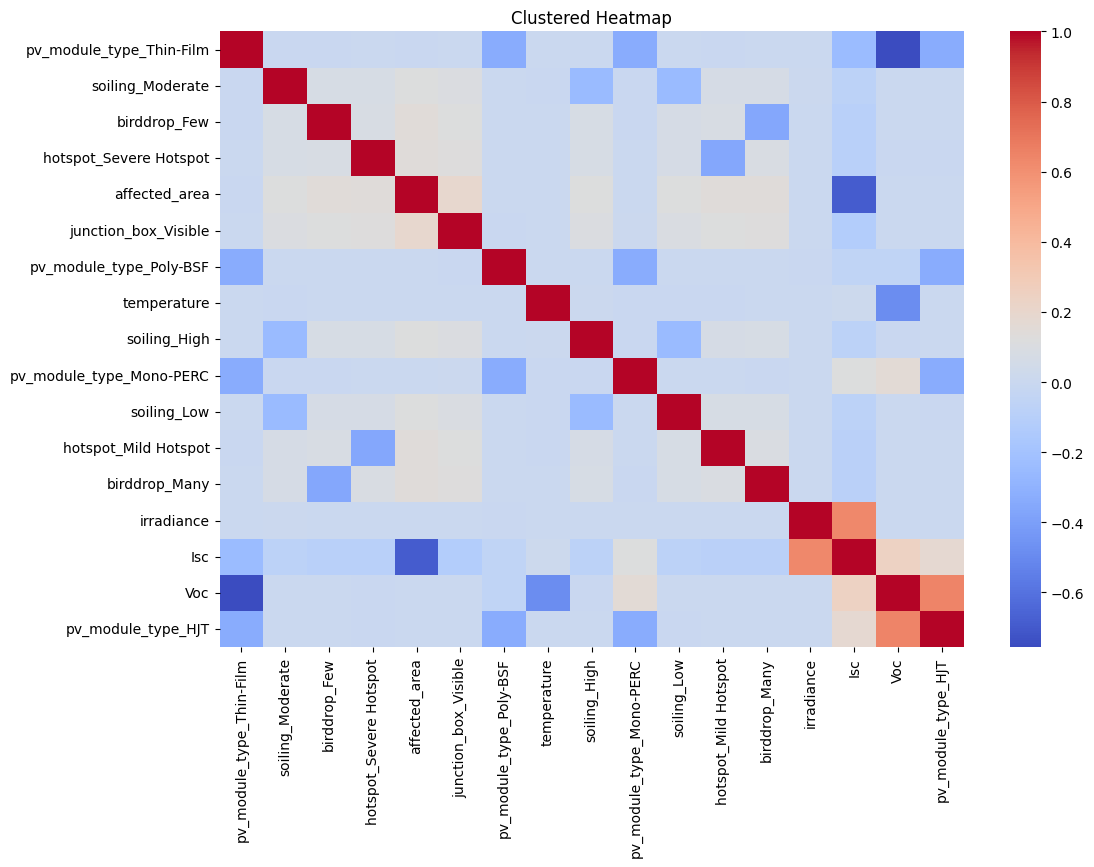

In [6]:
# Calculate the correlation matrix
corr_matrix = X.corr()

# Plot the heatmap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Import the linkage and leaves_list functions
from scipy.cluster.hierarchy import linkage, leaves_list


threshold = 0.1
thresholded_corr = corr_matrix.where((corr_matrix > threshold) | (corr_matrix < -threshold), np.nan)

# Plot the Thresholded Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(thresholded_corr, annot=True, cmap='coolwarm', mask=thresholded_corr.isnull())
plt.title('Thresholded Heatmap (|corr| > 0.1)')
plt.show()

# Perform hierarchical clustering on the correlation matrix
linkage_matrix = linkage(corr_matrix, method='ward')
ordered_indices = leaves_list(linkage_matrix)
clustered_corr = corr_matrix.iloc[ordered_indices, ordered_indices]

# Plot the Clustered Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(clustered_corr, annot=False, cmap='coolwarm')
plt.title('Clustered Heatmap')
plt.show()

## Splitting data
To define from the data which observations are the **training** and **testing** data, we need to split our dataset.
There are my possibilities, but some common spliting ratios are:

- 80/20 split: 80% of the data is used for training, and 20% is used for testing.
- 70/30 split: 70% for training, 30% for testing.
- Cross-validation (e.g., 5-fold or 10-fold): The dataset is divided into several parts, and multiple models are trained and validated by rotating the test set in each fold.


In [7]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets (for a simple 80/20 split)
X_train, X_test, y_efficiency_train, y_efficiency_test, y_efficiency_level_train, y_efficiency_level_test = train_test_split(
    X, y_efficiency, y_efficiency_level, test_size=0.2, random_state=42)

In [8]:
print("A training example:")
print(X_train.iloc[0])
print()
print("A test example:")
print(X_test.iloc[0])
print()

# Checking the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_efficiency_train shape:", y_efficiency_train.shape)
print("y_efficiency_train shape:", y_efficiency_test.shape)

# The types of outputs (y) are:
outputs = pd.unique(y_efficiency_level_train)
print("The types of outputs are:", outputs)

A training example:
affected_area               0.0494
temperature                   22.2
irradiance                   967.2
Voc                          45.49
Isc                          10.43
pv_module_type_HJT           False
pv_module_type_Mono-PERC      True
pv_module_type_Poly-BSF      False
pv_module_type_Thin-Film     False
hotspot_Mild Hotspot          True
hotspot_Severe Hotspot       False
birddrop_Few                  True
birddrop_Many                False
soiling_High                  True
soiling_Low                  False
soiling_Moderate             False
junction_box_Visible          True
Name: 75220, dtype: object

A test example:
affected_area               0.1393
temperature                   26.0
irradiance                  1022.6
Voc                          45.09
Isc                          10.11
pv_module_type_HJT           False
pv_module_type_Mono-PERC      True
pv_module_type_Poly-BSF      False
pv_module_type_Thin-Film     False
hotspot_Mild Hotspot      

## 1. k-Nearest Neighbour (kNN) model ##
(Introdução, podemos tirar daqui: https://www.geeksforgeeks.org/k-nearest-neighbours/ )

We will use:
- a **kNN Regressor**: to predict y_efficiency (regression task- continuous value);
- a **kNN Classifer**: to predict y_efficiency_level (classification task- discrete value);

How to choose the number of neighbours (k)?
- não sei !! p.s: vou fazer um ciclo para ver qual tem melhor accuracy, deu k=5... acho que isto é overfitting... mas pronto ahah

#### 1.1 kNN Regressor ####
documentação: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html 

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_efficiency_train)

# Predict on dataset which model has not seen before
print(knn.predict(X_test))

# Calculate the accuracy of the model
print(knn.score(X_test, y_efficiency_test))


[0.20484 0.16912 0.16904 ... 0.18154 0.19768 0.17362]
0.9401199573325616


#### 1.2 kNN Classifier ####
documentação que vi: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html 

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_efficiency_level_train)

# Predict on dataset which model has not seen before
print(knn.predict(X_test))

# Calculate the accuracy of the model
print(knn.score(X_test, y_efficiency_level_test))

['good' 'extremely_bad' 'extremely_bad' ... 'good' 'good' 'extremely_bad']
0.815


### 2. Linear regression ###
(Only for y_efficiency)
Guiei-me por este site: https://www.geeksforgeeks.org/ml-linear-regression/ 
- Since we have more than 1 independent feature, this is a Multiple Linear Regression;
- 

Se quiséssemos fazer uma regressão com os 2 outputs (variáveis dependentes), podemos seguir este site: https://www.geeksforgeeks.org/multivariate-regression/ 



Mean Squared Error: 1.4154310919550335e-06
R-squared: 0.9986798441844817


Text(0, 0.5, 'Predicted')

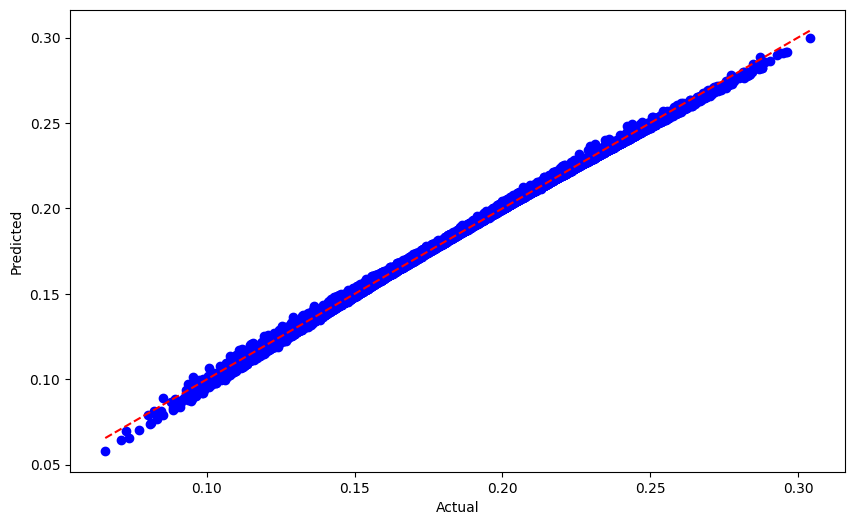

In [11]:
# Import libraries
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
linear_regressor = LinearRegression()

# Train the model on the training data
linear_regressor.fit(X_train, y_efficiency_train)

# Predict on the test data
y_pred = linear_regressor.predict(X_test)

# Calculate the Mean Squared Error
mse = mean_squared_error(y_efficiency_test, y_pred)
print("Mean Squared Error:", mse)

# Calculate the R-squared score
r2 = r2_score(y_efficiency_test, y_pred)
print("R-squared:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(y_efficiency_test, y_pred, color='blue')
plt.plot([y_efficiency_test.min(), y_efficiency_test.max()], [y_efficiency_test.min(), y_efficiency_test.max()], linestyle='--', color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')

## 2.1) Metrics: Accuracy, F1-score, confusion matrix, and ROC curve to evaluate performance across categories

## 3. K-Fold Cross-validation 

## 4. Naive Bayes Linear Classifier

https://penerbit.uthm.edu.my/ojs/index.php/jscdm/article/view/7144/3932
We have chosen 70:30 ratio because the Naive Bayes classifier is simplistic and cannot benefit from overfitting the data

Implementar possivelmente: Classification tasks often involve numeric attributes. For naive-Bayes classifiers,
numeric attributes are often preprocessed by discretization as the classification
performance tends to be better when numeric attributes are discretized than
when they are assumed to follow a normal distribution [9]. For each numeric
attribute X, a categorical attribute X∗
is created. Each value of X∗
corresponds
to an interval of values of X. X∗
is used instead of X for training a classifier. https://users.monash.edu/~webb/Files/YangWebb02a.pdf


Dúvida: pode-se separar as contínuas das discretas e depois multiplicar considerando que são independentes? Neste link fala sobre isso: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=7822560. Em princípio está certo

In [12]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score
import numpy as np


# Separate the continuous and binary features from the training and testing sets
X_train_continuous = X_train[['affected_area', 'temperature', 'irradiance', 'Voc', 'Isc']]
X_test_continuous = X_test[['affected_area', 'temperature', 'irradiance', 'Voc', 'Isc']]


X_train_binary = X_train[['pv_module_type_HJT', 'pv_module_type_Mono-PERC', 'pv_module_type_Poly-BSF',
                          'pv_module_type_Thin-Film', 'hotspot_Mild Hotspot', 'hotspot_Severe Hotspot',
                          'birddrop_Few', 'birddrop_Many', 'soiling_High', 'soiling_Low', 'soiling_Moderate',
                          'junction_box_Visible']]
X_test_binary = X_test[['pv_module_type_HJT', 'pv_module_type_Mono-PERC', 'pv_module_type_Poly-BSF',
                        'pv_module_type_Thin-Film', 'hotspot_Mild Hotspot', 'hotspot_Severe Hotspot',
                        'birddrop_Few', 'birddrop_Many', 'soiling_High', 'soiling_Low', 'soiling_Moderate',
                        'junction_box_Visible']]


# Initialize GaussianNB for continuous features
gnb = GaussianNB()
gnb.fit(X_train_continuous, y_efficiency_level_train)
proba_continuous = gnb.predict_proba(X_test_continuous)


# Initialize BernoulliNB for binary features
bnb = BernoulliNB()
bnb.fit(X_train_binary, y_efficiency_level_train)
proba_binary = bnb.predict_proba(X_test_binary)

# Average the probabilities from both models
mult_proba = proba_continuous * proba_binary # maybe do log because of underflow
mult_proba /= mult_proba.sum(axis=1, keepdims=True) # isn't really needed for the final result, but makes sure the sum of the probabilities of the 4 classifications is 1

# Convert averaged probabilities to final predictions
y_pred = np.argmax(mult_proba, axis=1)
y_pred = gnb.classes_[y_pred]  # Get class labels


# Calculate accuracy
accuracy = accuracy_score(y_efficiency_level_test, y_pred)
print("Hybrid Naive Bayes Model Accuracy:", accuracy)

Hybrid Naive Bayes Model Accuracy: 0.768


## 5. SVM (Support Vector Machine (SVM)), using One-vs-Rest (OvR) or One-vs-One (OvO) to create multiple binary classifiers


# 6. Random Forest


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
data = pd.read_csv("pv_module_efficiency_dataset.csv")

# Replace "None" with "Not Observed" in categorical columns
categorical_columns = ['pv_module_type', 'hotspot', 'birddrop', 'soiling', 'junction_box']
data[categorical_columns] = data[categorical_columns].replace("None", "Not Observed")

# Filter out rows where hotspot, birddrop, soiling, and junction_box are 'Not Observed' and there is an affected area
filtered_data = data[
    ~(
        (data['hotspot'] == 'Not Observed') &
        (data['birddrop'] == 'Not Observed') &
        (data['soiling'] == 'Not Observed') &
        (data['junction_box'] == 'Not Observed') &
        (data['affected_area'] > 0)
    )
]

# Separate the input features and target variables (output)
X = filtered_data.drop(["expected_efficiency", "efficiency_level"], axis=1)  # Input features
y = filtered_data['efficiency_level']  # Target variable

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, columns=['pv_module_type', 'hotspot', 'birddrop', 'soiling', 'junction_box'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Model Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Model Accuracy: 0.9814

Classification Report:
                precision    recall  f1-score   support

          bad       0.95      0.97      0.96      3081
extremely_bad       0.99      0.99      0.99      5354
         good       0.99      1.00      0.99     10240
     moderate       0.94      0.87      0.90      1325

     accuracy                           0.98     20000
    macro avg       0.97      0.96      0.96     20000
 weighted avg       0.98      0.98      0.98     20000


Confusion Matrix:
 [[ 2999    52     0    30]
 [   72  5282     0     0]
 [    0     0 10198    42]
 [   88     0    88  1149]]


# 7. Logistic Regression